# Preguntas de negocio

### 1. ¿Cuál es el impacto real de nuestra política de descuentos en el volumen de ventas?
* __Valor de negocio__: En MedTech, los ejecutivos de cuenta suelen dar descuentos para cerrar ventas, pero a veces esto solo erosiona el margen sin generar un aumento real en la adopción del producto. Necesitamos saber si "baratear" el equipo realmente funciona.
* __Concepto estadístico__: Correlación y Regresión Lineal Simple. No nos quedaremos con un simple gráfico de dispersión. Calcularemos el Coeficiente de Correlación de Pearson ($r$) entre Discount_Applied y Quantity. Además, plantearemos un modelo de regresión para estimar matemáticamente cuánto volumen extra genera cada punto porcentual de descuento, validando si el resultado es estadísticamente significativo a través de su $p-value$.

### 2. ¿Existen diferencias significativas en el ticket promedio de compra entre hospitales públicos y privados?
* __Valor de negocio__: Esto dicta hacia dónde dirigir el presupuesto de marketing y el esfuerzo de la fuerza de ventas. Si un sector gasta significativamente más, la estrategia de penetración debe ajustarse.
* __Concepto estadístico__: Prueba de Hipótesis (T-test para muestras independientes). Formularemos una hipótesis nula ($H_0$): "No hay diferencia en la media de ventas entre hospitales públicos y privados". Usaremos estadística inferencial para probar o rechazar esto con un nivel de confianza del 95% ($\alpha = 0.05$), demostrando que la diferencia no es producto del azar (ruido en los datos).

### 3. ¿Qué regiones o categorías de productos presentan anomalías severas en sus ventas (Outliers)?
* __Valor de negocio__: Un pico irreal de ventas puede ser un error de captura, fraude, o un éxito masivo temporal (ej. una licitación de gobierno). Identificarlos es vital para limpiar la proyección financiera.
* __Concepto estadístico__: Detección de valores atípicos (Outliers). Aplicaremos la regla del Rango Intercuartílico (IQR) y el cálculo de Z-scores ($Z = \frac{x - \mu}{\sigma}$). En el pipeline de limpieza, identificaremos matemáticamente qué transacciones se alejan más de 3 desviaciones estándar de la media para tratarlas antes de que ensucien el dashboard de Power BI.

### 4. ¿La satisfacción del cliente está ligada al volumen de equipos de imagenología adquiridos?
* __Valor de negocio__: Los equipos como tomógrafos o resonancias magnéticas requieren mantenimiento y servicio postventa. Queremos saber si una mala calificación de satisfacción nos está costando futuras compras de alto valor.
* __Concepto estadístico__: Análisis de Varianza (ANOVA) o Chi-Cuadrada. Primero aplicaremos técnicas de Imputación de Datos (como usar la media o mediana, o un modelo predictivo simple). Luego, dividiremos la satisfacción en categorías (Baja, Media, Alta) y aplicaremos ANOVA para ver si la varianza en las ventas de imagenología se explica por el nivel de satisfacción.

### 5. ¿Cuál es el comportamiento estacional y la tendencia de los productos consumibles frente a los quirúrgicos?
* __Valor de negocio__: Los consumibles (jeringas, gasas) deberían tener un flujo constante, mientras que los equipos quirúrgicos son compras esporádicas. Entender esta curva permite optimizar la cadena de suministro y evitar desabasto (stockouts) en el almacén.
* __Concepto estadístico__: Análisis de Series de Tiempo (Descomposición). Separaremos los datos en sus componentes fundamentales: tendencia (dirección a largo plazo), estacionalidad (patrones repetitivos) y ruido (variación aleatoria). Aplicaremos promedios móviles para suavizar las curvas de demanda y poder visualizar el verdadero comportamiento del mercado.

In [43]:
pip install pingouin

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 11.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ------------------------------ --------- 3/4 [pingouin]
   ---------------------------------------- 4/4 [pingoui

In [44]:
# importación de librerías 
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Carga de datos 

df = pd.read_csv("../data/raw/medtech_sales_data.csv")
df.head()

,Order_ID,Date,Hospital_Type,Region,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
0,ORD-3032,2023-01-01,Privado,Sur,Consumibles,Jeringas 5ml,492,14.00,0.06,6474.72,8.7
1,ORD-5157,2023-01-01,Privado,Centro,Consumibles,Guantes de Nitrilo,512,16.72,0.02,8389.43,8.8
2,ORD-4246,2023-01-01,Público,Norte,Consumibles,Guantes de Nitrilo,528,15.88,0.02,8216.95,6.8
3,ORD-4047,2023-01-01,Público,Occidente,Quirúrgicos,Bisturí Ultrasónico,5,4582.19,0.04,21994.51,10.0
4,ORD-2137,2023-01-01,Público,Occidente,Consumibles,Catéteres,554,15.21,0.04,8089.29,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               5000 non-null   str    
 1   Date                   5000 non-null   str    
 2   Hospital_Type          5000 non-null   str    
 3   Region                 4750 non-null   str    
 4   Product_Category       5000 non-null   str    
 5   Product_Name           5000 non-null   str    
 6   Quantity               5000 non-null   int64  
 7   Unit_Price_USD         5000 non-null   float64
 8   Discount_Applied       5000 non-null   float64
 9   Total_Sales_USD        5000 non-null   float64
 10  Customer_Satisfaction  4000 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 429.8 KB


**Nota:** 

Region y Customer_Satisfatcion tienen datos faltantes

In [11]:
# Limpieza de outliers 
z_scores = np.abs(stats.zscore(df['Quantity']))
df_clean = df[z_scores < 3].copy()
print(f"Registros preservados después de limpiar outliers: {len(df_clean)}")

Registros preservados después de limpiar outliers: 4992


In [14]:
# Corrección de datos faltantas 

    # Región
df_clean['Region'] = df_clean['Region'].fillna("Desconocido")

    # Satisfacción de clientes
median_satisfaction = df_clean['Customer_Satisfaction'].median()
df_clean['Customer_Satisfaction'] = df_clean['Customer_Satisfaction'].fillna(median_satisfaction)

df_clean.info()

<class 'pandas.DataFrame'>
Index: 4992 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               4992 non-null   str    
 1   Date                   4992 non-null   str    
 2   Hospital_Type          4992 non-null   str    
 3   Region                 4992 non-null   str    
 4   Product_Category       4992 non-null   str    
 5   Product_Name           4992 non-null   str    
 6   Quantity               4992 non-null   int64  
 7   Unit_Price_USD         4992 non-null   float64
 8   Discount_Applied       4992 non-null   float64
 9   Total_Sales_USD        4992 non-null   float64
 10  Customer_Satisfaction  4992 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 468.0 KB


**Nota** 

Se eliminaron 8 registros después de la limpieza de outliers; no se tienen más datos null en el dataframe. 

In [21]:
# Correlación entre descuento y volumen de venta 
corr, p_value_corr = stats.pearsonr(df_clean['Discount_Applied'], df_clean['Quantity'])
print(f"Coeficiente de correlación(r): {corr:.2f}")
print(f"P valor : {p_value_corr:.2f}")

Coeficiente de correlación(r): -0.01
P valor : 0.66


**Nota** 

No se muestra una relación entre los descuentos aplicados y el volúmen de compra. Se debe revisar si existe diferencia en la correlación para diferentes segmentos de clientes. 

Tipo de cliente: Privado

- Coeficiente pearson: -0.01

- P-value: 0.84

 * Resultado no significativo

Tipo de cliente: Público

- Coeficiente pearson: 0.01

- P-value: 0.75

 * Resultado no significativo

Tipo de cliente: Clínica Especializada

- Coeficiente pearson: -0.04

- P-value: 0.20

 * Resultado no significativo



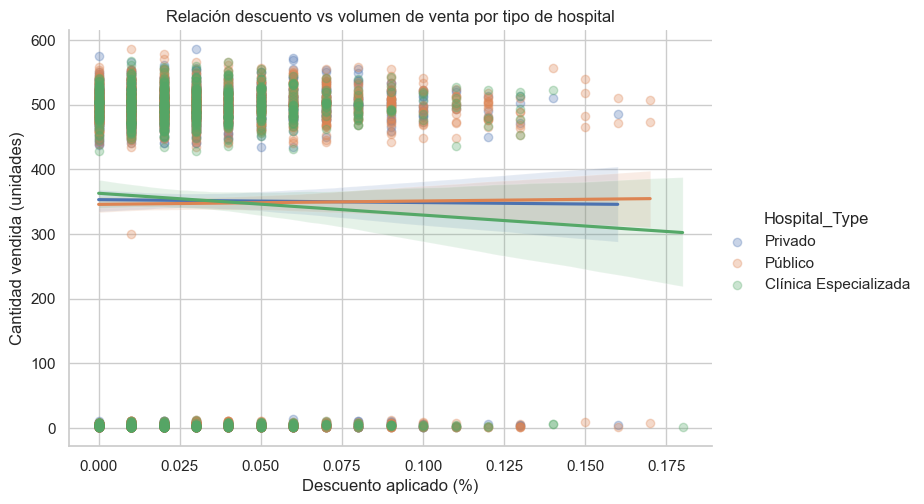

In [32]:
# Correlación para otros segmentos de mercado

for h_type in df_clean['Hospital_Type'].unique():
    subset = df_clean[df_clean['Hospital_Type'] == h_type]
    r, p_value_corr = stats.pearsonr(subset['Discount_Applied'], subset['Quantity'])
    print(f"Tipo de cliente: {h_type}")
    print(f"\n- Coeficiente pearson: {r:.2f}")
    print(f"\n- P-value: {p_value_corr:.2f}")

    if p_value_corr < 0.05:
        print("\n * Resultado estadístico significativa")
    else:
        print("\n * Resultado no significativo\n")



# Visualización de tendencia 
sns.set_theme(style = 'whitegrid')
g = sns.lmplot(
    data = df_clean, 
    x = 'Discount_Applied', 
    y= 'Quantity', 
    hue = 'Hospital_Type',
    height= 5, 
    aspect= 1.5, 
    scatter_kws={'alpha': 0.3}
)

g.set_axis_labels("Descuento aplicado (%)", "Cantidad vendida (unidades)")
plt.title("Relación descuento vs volumen de venta por tipo de hospital")
plt.show()


*Nota:*

No hay correlación entre el descuento aplicado y el volumen de venta para los segmentos de clientes. 

In [35]:
# Comparación del ticket promedio de hospítal público vs privado 

ventas_publico = df_clean[df_clean['Hospital_Type']== 'Público']['Total_Sales_USD']
ventas_privado = df_clean[df_clean['Hospital_Type']== 'Privado']['Total_Sales_USD']

t_stat, p_value_t = stats.ttest_ind(ventas_publico, ventas_privado, equal_var = False)

if p_value_t < 0.05:
    print(f"Existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")
else:
    print(f"No existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")

No existe una diferencia estadística significativa entre las medias de venta a hospital público: 37653.98 y venta a hospital privado 37776.44
Estadístico T= -0.04 | P-valor =0.97


In [39]:
# Compración del ticket promedio entre los diferente tipos de hosptiales en el dataset 

# Se usa ANOVA y post-hoc la prueba de Tukey y Games-Howell (asume heterocedasticidad)
grupos = [df_clean[df_clean['Hospital_Type'] == h]['Total_Sales_USD'] for h in df_clean['Hospital_Type'].unique()]

f_stat, p_value_anova = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.2f}")
print(f"Valor P ANOVA: {p_value_anova:.2f}")

Estadístico F: 0.15
Valor P ANOVA: 0.86


In [41]:
# Prueba de Tukey 

tukey = pairwise_tukeyhsd(
    endog= df_clean['Total_Sales_USD'], 
    groups= df_clean['Hospital_Type'], 
    alpha = 0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
        group1         group2  meandiff  p-adj     lower      upper   reject
----------------------------------------------------------------------------
Clínica Especializada Privado -1745.4412 0.8958 -10901.5583 7410.6759  False
Clínica Especializada Público -1867.8984 0.8609 -10268.2365 6532.4397  False
              Privado Público  -122.4572 0.9992  -7435.2182 7190.3038  False
----------------------------------------------------------------------------


In [45]:
gh_test = pg.pairwise_gameshowell(
    data = df_clean, 
    dv = 'Total_Sales_USD', 
    between = 'Hospital_Type'
)

print(gh_test)

                       A        B        mean_A        mean_B         diff  \
0  Clínica Especializada  Privado  39521.882354  37776.441144  1745.441210   
1  Clínica Especializada  Público  39521.882354  37653.983960  1867.898394   
2                Privado  Público  37776.441144  37653.983960   122.457184   

            se         T           df      pval    hedges  
0  4099.487915  0.425771  2061.593619  0.904926  0.017555  
1  3716.992601  0.502529  1664.099849  0.870102  0.019741  
2  3114.647076  0.039317  3004.604214  0.999148  0.001304  
